<b>Experiments on time-series analysis and optimizations</b>

https://colab.research.google.com/drive/1yAeDBAPuhxg0-OgIsTB4pLggwCg4yl8k?usp=sharing

https://colab.research.google.com/drive/14bDZvKC-cSXfYLsi5HIGUaTiNxpOXry6?usp=sharing

https://colab.research.google.com/drive/1oHOLUBY5zvW-K3E3lVFeJIuMMOPKXbj4?usp=sharing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load dataset
file_path = "AirQualityUCI.csv"
data = pd.read_csv(file_path, sep=";", decimal=",")

# Manually format the 'Date' and 'Time' columns into a proper datetime format
# First, replace the '.' in 'Time' column with ':' to make it a valid time format
data['Time'] = data['Time'].str.replace('.', ':')

# Combine the 'Date' and 'Time' into a single datetime column
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], dayfirst=True)

# Select relevant columns
columns = ["Datetime", "CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "C6H6(GT)", "T", "RH", "AH"]
data = data[columns]

# Select only numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns  
data[numerical_cols] = data[numerical_cols].replace(-200, np.nan)

# Interpolation
# data["C6H6(GT)"] = data["C6H6(GT)"].interpolate(method="linear")
# data["PT08.S1(CO)"] = data["PT08.S1(CO)"].interpolate(method="linear")
data[numerical_cols] = data[numerical_cols].interpolate(method="linear")


<b>Seasonal decomposition</b>

In [2]:
%matplotlib inline

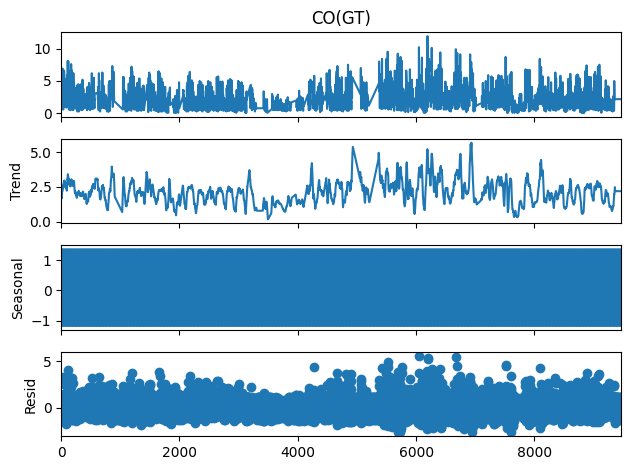

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the CO(GT) variable
result = seasonal_decompose(data["CO(GT)"], model="additive", period=24)
result.plot()
plt.show()

# how to read:

# trend = observe the main trend, is it going up, remains neutral or is it going down?
# even with the spikes to -200 (missing values), the generic trend in this case seems to be stable

# seasonal = huge slab like this indicates heavy seasonality

# residual = ideal case => all points are random like white noise
# this dataset actually has some structure, so it's not ideal

# ask ChatGPT, for example, for more details how to read these plots
# see also the Colab notebooks from the start of this notebook

<b>Smoothing the signal with a rolling average</b>

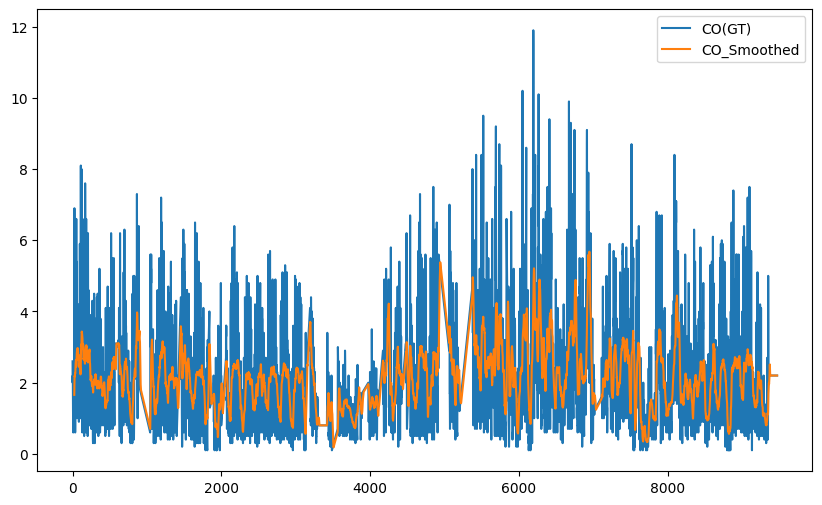

In [4]:
# Apply a rolling average to smooth CO(GT)
data["CO_Smoothed"] = data["CO(GT)"].rolling(window=24).mean()

# Plot original vs smoothed
data[["CO(GT)", "CO_Smoothed"]].plot(figsize=(10, 6))
plt.show()


<b>Fourier Transform</b>

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_7044\3861184271.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_f = data['CO(GT)'].copy().fillna(method='ffill').values


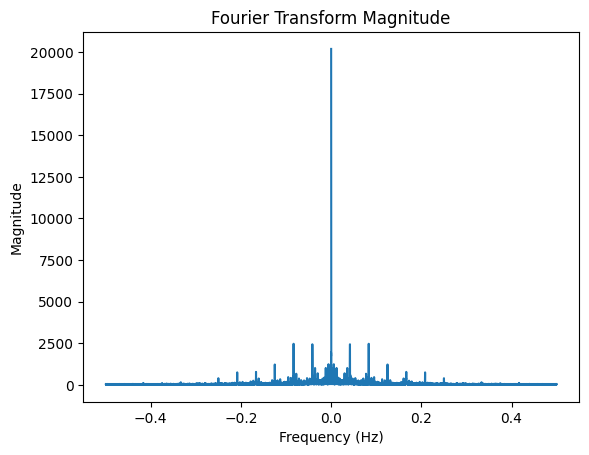

In [5]:
# Ensure you have the data as a 1D array
data_f = data['CO(GT)'].copy().fillna(method='ffill').values

# Apply Fourier Transform
fft_result = np.fft.fft(data_f)

# Get the corresponding frequency bins
frequencies = np.fft.fftfreq(len(data_f))

# Plot the magnitude of the Fourier Transform (absolute value)
plt.plot(frequencies, np.abs(fft_result))
plt.title('Fourier Transform Magnitude')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()


# in Fourier transform magnitude plot
# huge central spike usually implies lack of noise
# in this case, there's some noise in the sides


<b>Dynamic Time Warping</b>

<b>Interpolating between missing values can be done with pandas!</b>

<b>Compare the original data without interpolation and after interpolation</b>

DTW distance: 4481.188025155344


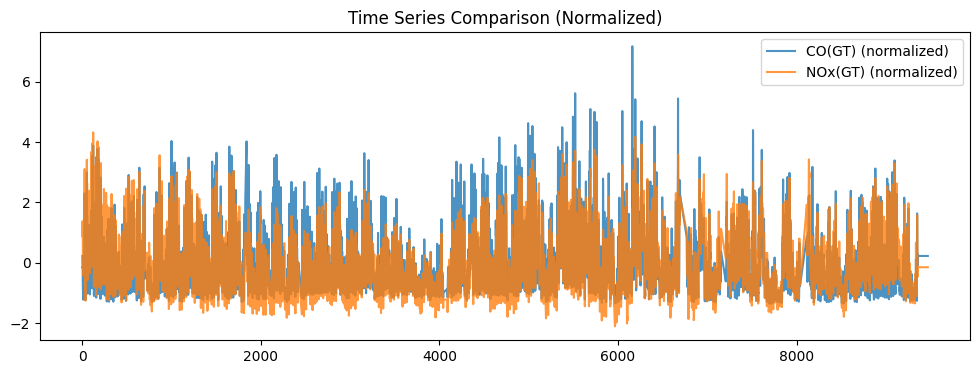

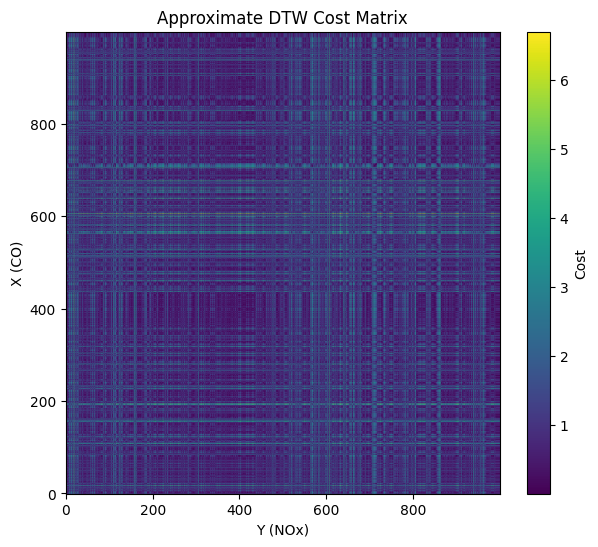

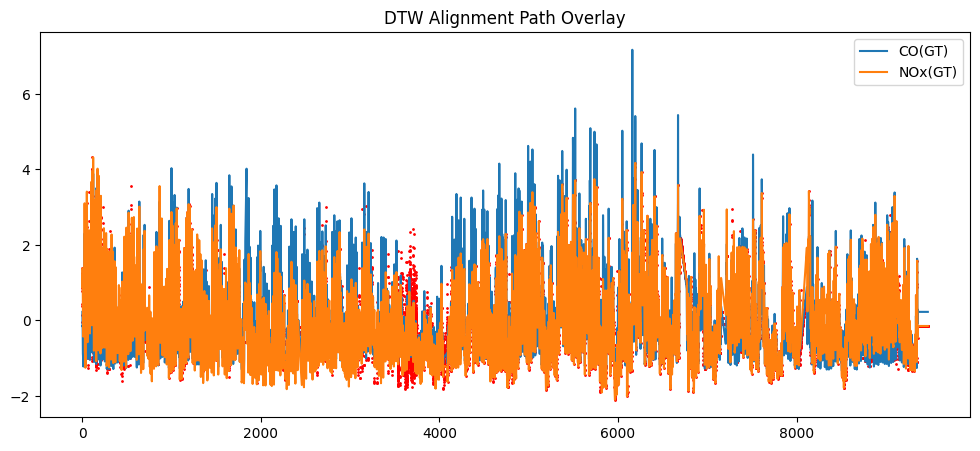

In [6]:


# Plot original and interpolated data
# data_missing[["CO(GT)", "CO_Interpolated"]].plot(figsize=(10, 6))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import cdist

# -----------------------------------------
# Load and preprocess data
# -----------------------------------------

x = data['C6H6(GT)'].values
y = data['PT08.S1(CO)'].values

# Normalize both signals
scaler = StandardScaler()
x_norm = scaler.fit_transform(x.reshape(-1,1)).flatten()
y_norm = scaler.fit_transform(y.reshape(-1,1)).flatten()

# DTW formatting
x_t = [(xi,) for xi in x_norm]
y_t = [(yi,) for yi in y_norm]

# Compute DTW
distance, path = fastdtw(x_t, y_t, dist=euclidean)
print("DTW distance:", distance)

# -----------------------------------------
# 1. Plot the two signals
# -----------------------------------------
plt.figure(figsize=(12,4))
plt.plot(x_norm, label="CO(GT) (normalized)", alpha=0.8)
plt.plot(y_norm, label="NOx(GT) (normalized)", alpha=0.8)
plt.legend()
plt.title("Time Series Comparison (Normalized)")
plt.show()

# -----------------------------------------
# 2. Reconstruct a cost matrix for visualization
# (fastdtw does not output one, so compute pairwise)
# -----------------------------------------
# Downsample for visualization if signals are huge
N = 1000  # reduce if needed
x_small = np.linspace(0, len(x_norm)-1, N).astype(int)
y_small = np.linspace(0, len(y_norm)-1, N).astype(int)

Xsmall = x_norm[x_small].reshape(-1, 1)
Ysmall = y_norm[y_small].reshape(-1, 1)

cost_matrix = cdist(Xsmall, Ysmall, 'euclidean')

plt.figure(figsize=(7,6))
plt.imshow(cost_matrix, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label="Cost")
plt.title("Approximate DTW Cost Matrix")
plt.xlabel("Y (NOx)")
plt.ylabel("X (CO)")
plt.show()

# -----------------------------------------
# 3. Plot the warping path on top of signals
# -----------------------------------------
px = [p[0] for p in path]
py = [p[1] for p in path]

plt.figure(figsize=(12,5))
plt.plot(x_norm, label="CO(GT)")
plt.plot(y_norm, label="NOx(GT)")
plt.scatter(px, y_norm[py], s=1, c="red")  # red = matched points
plt.title("DTW Alignment Path Overlay")
plt.legend()
plt.show()
